# SGNN: Stochastic SIR/SEIR/SEAIR


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [2]:
#SIR Simulation

# N - population size; T - Number of days
def simulate_sir(N = 200000, T = 128):
    # Random starting values
    # Transmission rate (beta-how fast infection spreads)
    beta = np.random.uniform(0.15, 0.45)
    
    # Recovery rate (gamma-how fast people recover)
    gamma = np.random.uniform(0.07, 0.25)
    
    # Infected people. This randomly chooses the starting number of infected people between 5 and 49
    I0 = np.random.randint(5, 50)

    # starting values
    # S-Susceptible people who can catch the disease
    S = N - I0
    # I-Infected people
    I = I0
    # R-Recovered people
    R = 0

    # history lists - these are empty lists that will store the values for each day
    S_hist = []
    I_hist = []
    R_hist = []
    # New infections each day
    new_inf_hist = []

    # simulating for for every day
    # This loop runs for each day from T = 0 to T = 127
    for day in range(T):
        # how strongly infection spreads today
        # calculates infection pressure for the day
        force = beta * I / N

        # expected new infections  (how many new infections we expect today)
        expected_new_inf = force * S # (More people are susceptible, more new infections can happen)
        
        # Adding randomness to new infections
        new_inf = np.random.poisson(expected_new_inf)

        # This makes sure new infections cannot be more than the number of susceptible people left.
        new_inf = min(new_inf, int(S))

        # expected new recoveries
        expected_new_rec = gamma * I
        # Adding randomness to new recoveries
        new_rec = np.random.poisson(expected_new_rec)
        # This makes sure recoveries cannot be more than the number of infected people.
        new_rec = min(new_rec, int(I))

        # updating the counts of S, I, R
        S = S - new_inf
        I = I + new_inf - new_rec
        R = R + new_rec

        # storing the daily values
        S_hist.append(S)
        I_hist.append(I)
        R_hist.append(R)
        new_inf_hist.append(new_inf)

    # Dictionary that the function will return
    return {
        "model_type": "SIR",
        "population": N,
        "beta": beta,
        "gamma": gamma,
        "I0": I0,
        "daily_new_cases_true": np.array(new_inf_hist, dtype=int),
        # combining three history list (susceptible, infected, recovered)
        "compartments": np.stack([S_hist, I_hist, R_hist], axis=1)
    }

In [3]:
# SEIR Simulation

# N - population size; T - Number of days
def simulate_seir(N = 200000, T = 128):
    # Random starting values
    # Transmission rate (beta-how fast infection spreads)
    beta = np.random.uniform(0.15, 0.45)
    
    # exposed -> infected rate
    sigma = np.random.uniform(0.15, 0.50)
    # Recovery rate (gamma-how fast people recover)
    gamma = np.random.uniform(0.07, 0.25)
    
    # Exposed people - Initial number of exposed people between 5 and 49
    E0 = np.random.randint(5, 50)
    
    # starting values
    # S-Susceptible people who can catch the disease
    S = N - E0
    #E-Exposed people
    E = E0
    # I-Infected people
    I = 0
    # R-Recovered people
    R = 0

    # history lists
    S_hist = []
    E_hist = []
    I_hist = []
    R_hist = []
    new_inf_hist = []

    # simulating for for every day
    for day in range(T):
        # how strongly infection spreads today
        force = beta * I / N

        # expected new infections (susceptible to exposed)
        expected_new_inf = force * S
        # random number for new infections
        new_inf = np.random.poisson(expected_new_inf)
        new_inf = min(new_inf, int(S))

        # new exposed people become infected (exposed to infected)
        expected_new_inc = sigma * E
        #random number for exposed
        new_inc = np.random.poisson(expected_new_inc)
        new_inc = min(new_inc, int(E))
      
        # expected new recoveries
        expected_new_rec = gamma * I
        # random number for new recoveries
        new_rec = np.random.poisson(expected_new_rec)
        new_rec = min(new_rec, int(I))

        # updating the counts of S, I, R
        S = S - new_inf
        E = E + new_inf - new_inc
        I = I + new_inc - new_rec
        R = R + new_rec

        # storing the daily values
        S_hist.append(S)
        E_hist.append(E)
        I_hist.append(I)
        R_hist.append(R)
        new_inf_hist.append(new_inf)

    # Dictionary that the function will return
    return {
        "model_type": "SEIR",
        "population": N,
        "beta": beta,
        "sigma": sigma,
        "gamma": gamma,
        "E0": E0,
        "daily_new_cases_true": np.array(new_inf_hist, dtype=int),
        # combining the four history lists (susceptible, exposed, infected, recovered)
        "compartments": np.stack([S_hist, E_hist, I_hist, R_hist], axis=1)
    }

In [4]:
# Simulation for SEAIR

# N - population size; T - Number of days
def simulate_seair(N = 200000, T = 128):
    # Random starting values
    # Transmission rate (beta-how fast infection spreads)
    beta = np.random.uniform(0.15, 0.45)
    # exposed - infected rate
    sigma = np.random.uniform(0.15, 0.50)
    # recovery rate for asymptomatic
    gamma_a = np.random.uniform(0.07, 0.25)
    # recovery rate for symptomatic
    gamma_i = np.random.uniform(0.07, 0.25)
    # chance of exposed becoming asymptomatic
    p_a = np.random.uniform(0.2, 0.6)
    # starting exposed people
    E0 = np.random.randint(5, 50)

    # starting values
    # S-Susceptible people who can catch the disease
    S = N - E0
    # E-Exposed
    E = E0
    # A-Asymptomatic
    A = 0
    # I-Infected
    I = 0
    # R-Recovered
    R = 0

    # history lists
    S_hist = []
    E_hist = []
    A_hist = []
    I_hist = []
    R_hist = []
    new_inf_hist = []

    # simulating for each day
    for day in range(T):
        # infection spread strength (from asymptomatic and symptomatic people)
        force = beta * (A + I) / N

        # expected new infections (S to E)
        expected_new_inf = force * S
        # random number for new infections
        new_inf = np.random.poisson(expected_new_inf)
        new_inf = min(new_inf, int(S))
        
        # exposed people become infected
        expected_new_inc = sigma * E
        # random number for people moving from exposed to infectious
        new_inc = np.random.poisson(expected_new_inc)
        new_inc = min(new_inc, int(E))

        # split new infectious people into asymptomatic and symptomatic
        to_A = np.random.binomial(new_inc, p_a)
        to_I = new_inc - to_A

        # expected number of recoveries from asymptomatic and symptomatic people
        expected_rec_a = gamma_a * A #anymptomatic
        expected_rec_i = gamma_i * I #symptomatic

        # random number for recoveries
        rec_a = np.random.poisson(expected_rec_a)
        rec_i = np.random.poisson(expected_rec_i)

        rec_a = min(rec_a, int(A))
        rec_i = min(rec_i, int(I))
    
        # updated counts for S, E, A, I, R
        S = S - new_inf             #succeptable
        E = E + new_inf - new_inc   #exposed
        A = A + to_A - rec_a        #asymptomatic infected
        I = I + to_I - rec_i        #symptomatic infected
        R = R + rec_a + rec_i       #recovery
    
        # storing the daily values
        S_hist.append(S)
        E_hist.append(E)
        A_hist.append(A)
        I_hist.append(I)
        R_hist.append(R)
        new_inf_hist.append(new_inf)

    # Dictionary that the function will return
    return {
        "model_type": "SEAIR",
        "population": N,
        "beta": beta,
        "sigma": sigma,
        "gamma_a": gamma_a,
        "gamma_i": gamma_i,
        "p_a": p_a,
        "E0": E0,
        "daily_new_cases_true": np.array(new_inf_hist, dtype=int),
        # combining the five history lists (susceptible, exposed, asymptotic, infected, recovered)
        "compartments": np.stack([S_hist, E_hist, A_hist, I_hist, R_hist], axis=1)
    }

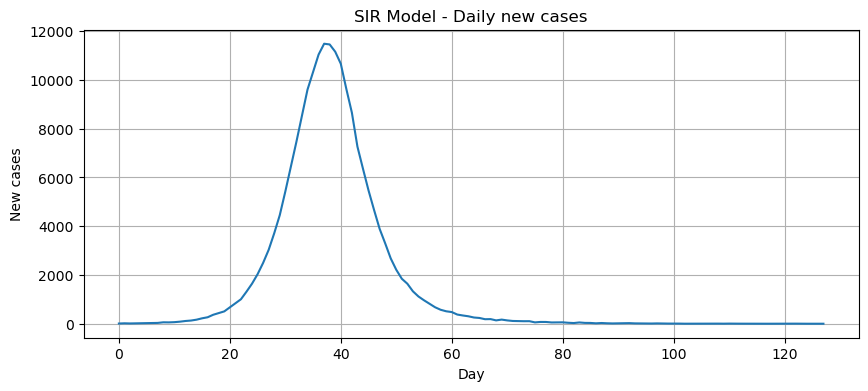

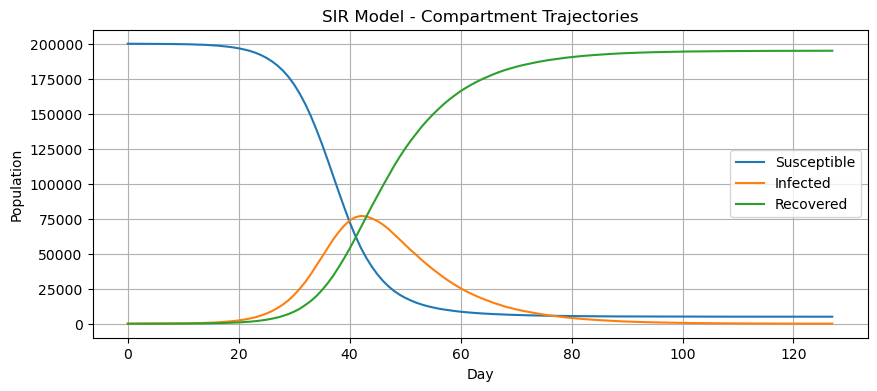

In [5]:
# running one SIR simulation
sir_sample = simulate_sir()

# Extracting outputs
daily_cases = sir_sample["daily_new_cases_true"]
compartments = sir_sample["compartments"]

# Plotting daily new cases
plt.figure(figsize=(10, 4))
plt.plot(daily_cases)
plt.title("SIR Model - Daily new cases")
plt.xlabel("Day")
plt.ylabel("New cases")
plt.grid(True)
plt.show()

# Compartments
plt.figure(figsize=(10, 4))

plt.plot(compartments[:, 0], label="Susceptible")
plt.plot(compartments[:, 1], label="Infected")
plt.plot(compartments[:, 2], label="Recovered")

plt.title("SIR Model - Compartment Trajectories")
plt.xlabel("Day")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()

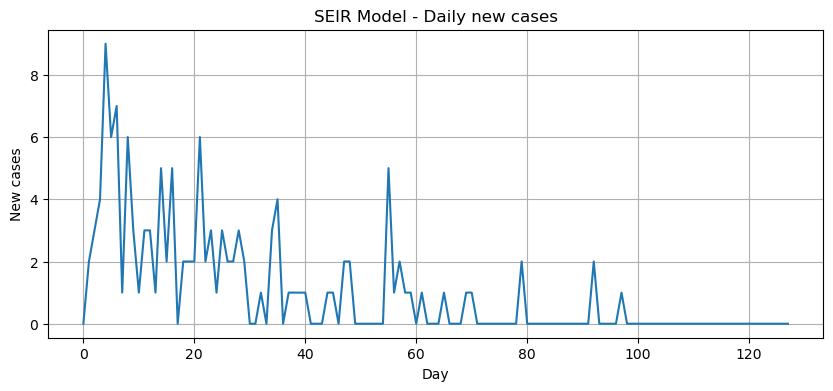

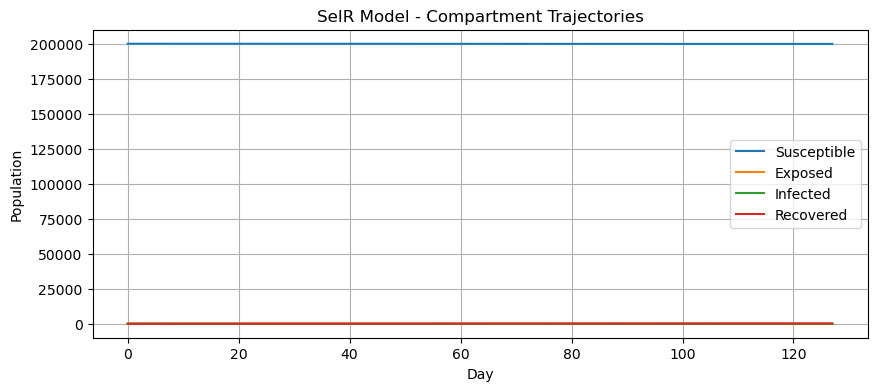

In [6]:
# running one SEIR simulation
seir_sample = simulate_seir()

# Extracting outputs
daily_cases = seir_sample["daily_new_cases_true"]
compartments = seir_sample["compartments"]

# Plotting daily new cases
plt.figure(figsize=(10, 4))
plt.plot(daily_cases)

plt.title("SEIR Model - Daily new cases")
plt.xlabel("Day")
plt.ylabel("New cases")
plt.grid(True)
plt.show()

# Compartments
plt.figure(figsize=(10, 4))

plt.plot(compartments[:, 0], label="Susceptible")
plt.plot(compartments[:, 1], label="Exposed")
plt.plot(compartments[:, 2], label="Infected")
plt.plot(compartments[:, 3], label="Recovered")


plt.title("SeIR Model - Compartment Trajectories")
plt.xlabel("Day")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()

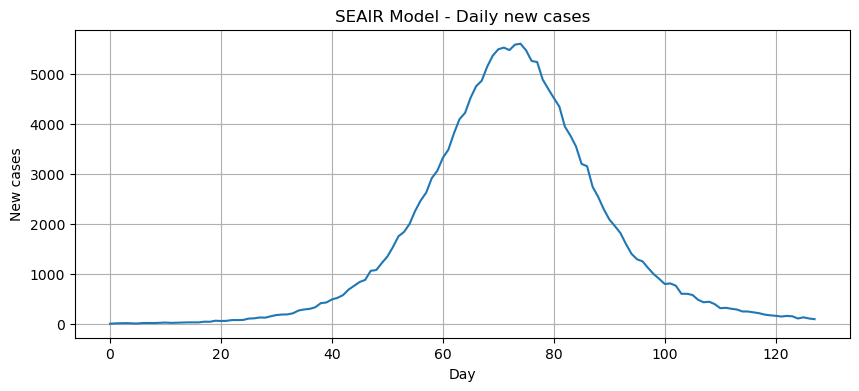

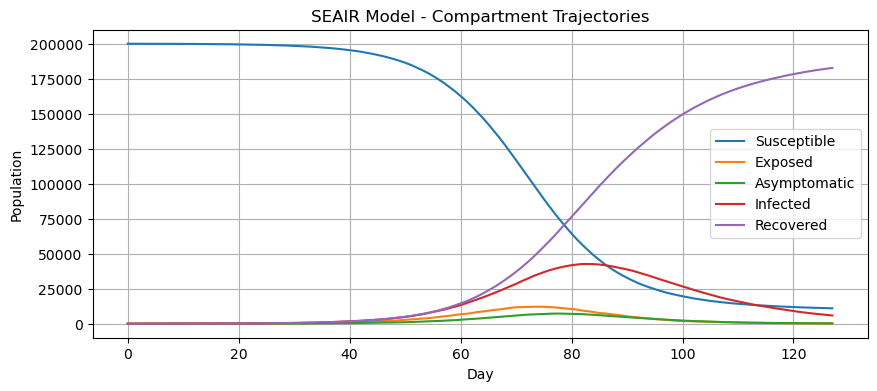

In [7]:
# running one SEAIR simulation
seair_sample = simulate_seair()

# Extracting outputs
daily_cases = seair_sample["daily_new_cases_true"]
compartments = seair_sample["compartments"]

# Plotting daily new cases
plt.figure(figsize=(10, 4))
plt.plot(daily_cases)

plt.title("SEAIR Model - Daily new cases")
plt.xlabel("Day")
plt.ylabel("New cases")
plt.grid(True)
plt.show()

# Compartments
plt.figure(figsize=(10, 4))

plt.plot(compartments[:, 0], label="Susceptible")
plt.plot(compartments[:, 1], label="Exposed")
plt.plot(compartments[:, 2], label="Asymptomatic")
plt.plot(compartments[:, 3], label="Infected")
plt.plot(compartments[:, 4], label="Recovered")

plt.title("SEAIR Model - Compartment Trajectories")
plt.xlabel("Day")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Function to create one outbreak sample

def simulate_one_sample(N=200000, T=128):
    # Randomly choosing epidemic model to use: SIR, SEIR, or SEAIR
    model_name = np.random.choice(["SIR", "SEIR", "SEAIR"])

    # If the chosen model is SIR, run the SIR simulation
    if model_name == "SIR":
        return simulate_sir(N=N, T=T)

    # If the chosen model is SEIR, run the SEIR simulation
    elif model_name == "SEIR":
        return simulate_seir(N=N, T=T)

    # Otherwise, use the SEAIR simulation
    else:
        return simulate_seair(N=N, T=T)

In [9]:
sample = simulate_one_sample()

print("Model type:", sample["model_type"])
print("First 10 daily cases:", sample["daily_new_cases_true"][:10])
print("Compartment shape:", sample["compartments"].shape)

Model type: SEIR
First 10 daily cases: [ 0  1  7  5  6  5  9  7 12 16]
Compartment shape: (128, 4)


In [10]:
# Generating dataset

def generate_dataset(num_samples=1000, N=200000, T=128):
    # Store one dictionary per outbreak sample
    rows = []

    # GEnerating many outbreaks
    for i in range(num_samples):
        
        sample = simulate_one_sample(N=N, T=T)
        # Storing model information
        row = {
            # Store model name (SIR, SEIR, or SEAIR)
            "model_type": sample["model_type"],
            # Store the population size used in the simulation
            "population": sample["population"],
            # Store model parameters if they exist
            "beta": sample.get("beta", np.nan),
            "gamma": sample.get("gamma", np.nan),
            "sigma": sample.get("sigma", np.nan),
            "gamma_a": sample.get("gamma_a", np.nan),
            "gamma_i": sample.get("gamma_i", np.nan),
            "p_a": sample.get("p_a", np.nan),
            "I0": sample.get("I0", np.nan),
            "E0": sample.get("E0", np.nan)
        }
        
        # Store daily case counts
        for t in range(T):
            row[f"true_cases_day_{t}"] = sample["daily_new_cases_true"][t]

        rows.append(row)

    return pd.DataFrame(rows)

In [11]:
#
df = generate_dataset(num_samples=1000, N=200000, T=128)

print("Dataset shape:", df.shape)
print("\nModel counts:")
print(df["model_type"].value_counts())

df.head()

Dataset shape: (1000, 138)

Model counts:
model_type
SIR      350
SEIR     326
SEAIR    324
Name: count, dtype: int64


,model_type,population,beta,gamma,sigma,gamma_a,gamma_i,p_a,I0,E0,...,true_cases_day_118,true_cases_day_119,true_cases_day_120,true_cases_day_121,true_cases_day_122,true_cases_day_123,true_cases_day_124,true_cases_day_125,true_cases_day_126,true_cases_day_127
0,SEIR,200000,0.424639,0.128957,0.202389,NaN,NaN,NaN,NaN,35.0,...,47,34,38,33,23,23,14,19,13,13
1,SEIR,200000,0.385678,0.075904,0.320388,NaN,NaN,NaN,NaN,36.0,...,9,6,5,2,2,4,3,0,1,0
2,SEIR,200000,0.425072,0.167335,0.158159,NaN,NaN,NaN,NaN,23.0,...,966,967,796,797,726,708,644,542,517,494
3,SEAIR,200000,0.431277,NaN,0.342570,0.183052,0.239088,0.596622,NaN,35.0,...,89,90,78,58,50,45,43,38,43,24
4,SEAIR,200000,0.201409,NaN,0.390289,0.212954,0.088605,0.225930,NaN,8.0,...,715,729,798,810,883,942,902,1107,1047,1093


In [12]:
# saving dataset
df.to_csv("sir_seir_seair_dataset.csv", index=False)


In [13]:
# Choosing input and target days
input_days = 100
target_days = 28

In [14]:
# Building input and target column names
# This creates two sets of column names that the model will use- input days and target days

# This is creating column names ["true_cases_day_0", "true_cases_day_1", "true_cases_day_99"]
input_cols = [f"true_cases_day_{t}" for t in range(input_days)]

# This is creating column names ["true_cases_day_100", "true_cases_day_101", "true_cases_day_127"]
target_cols = [f"true_cases_day_{t}" for t in range(input_days, input_days + target_days)]

In [15]:
# Creating X (input data or features) and y (target data) arrays
# X contains the first 100 days of daily cases, and y contains the next 28 days that the model should predict

# This turns pandas dataframe to NumPy array. This is done so that it works better with PyTorch.

X = df[input_cols].to_numpy(dtype=np.float32)
y = df[target_cols].to_numpy(dtype=np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 100)
y shape: (1000, 28)


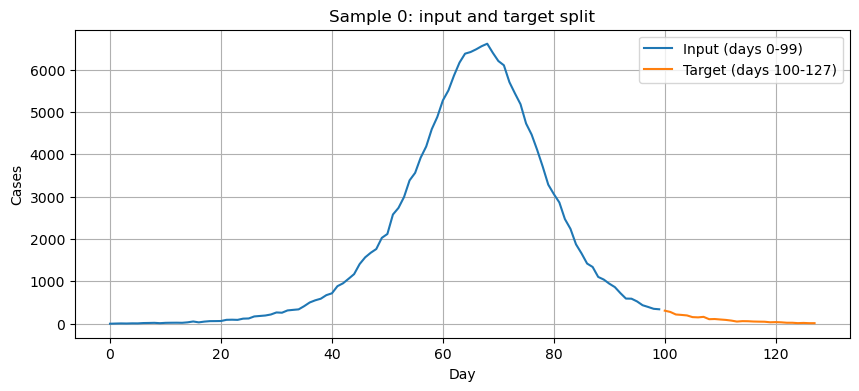

In [16]:
# sample for plotting
sample_idx = 0
x_input = np.arange(input_days)
x_target = np.arange(input_days, input_days + target_days)

plt.figure(figsize=(10, 4))
plt.plot(x_input, X[sample_idx], label="Input (days 0-99)")
plt.plot(x_target, y[sample_idx], label="Target (days 100-127)")
plt.title(f"Sample {sample_idx}: input and target split")
plt.xlabel("Day")
plt.ylabel("Cases")
plt.grid(True)
plt.legend()
plt.show()

In [17]:
# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 100)
X_test shape: (200, 100)
y_train shape: (800, 28)
y_test shape: (200, 28)


In [18]:
# Converting NumPy arrays to PyTorch tensors. This is the data type PyTorch model expects
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [19]:
# Simple neural network

# Input: first 100 days; Output: next 28 days
# 100 inputs; one hiddel layer with 64 neurons; 28 outputs
# ReLU() is the activation function that adds nonlinearity and helps the model learn more complex patterns

model = nn.Sequential(nn.Linear(100, 64), nn.ReLU(), nn.Linear(64, 28))

In [20]:
# Defining loss and optimizer

# This creates the loss function: MSELoss - Mean squared error
criterion = nn.MSELoss()

# This creates the optimizer
# Adam is the method that updates the model's weight so the loss gets smaller
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train the model for 50 full passes through the training data
epochs = 50

# storing loss from each epoch
train_losses = []

for epoch in range(epochs):
    model.train()

    # clears old gradiants from previous step
    optimizer.zero_grad()

    y_pred = model(X_train_tensor)

    # Comparing the predictions with the true training values and calculates the error
    loss = criterion(y_pred, y_train_tensor)
    # computes gradients
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss= {loss.item(): .6f}")

Epoch 5/50, Loss=  1058330.000000
Epoch 10/50, Loss=  893586.625000
Epoch 15/50, Loss=  779430.562500
Epoch 20/50, Loss=  684667.500000
Epoch 25/50, Loss=  598908.250000
Epoch 30/50, Loss=  527861.687500
Epoch 35/50, Loss=  468937.500000
Epoch 40/50, Loss=  420789.312500
Epoch 45/50, Loss=  381392.781250
Epoch 50/50, Loss=  348932.625000


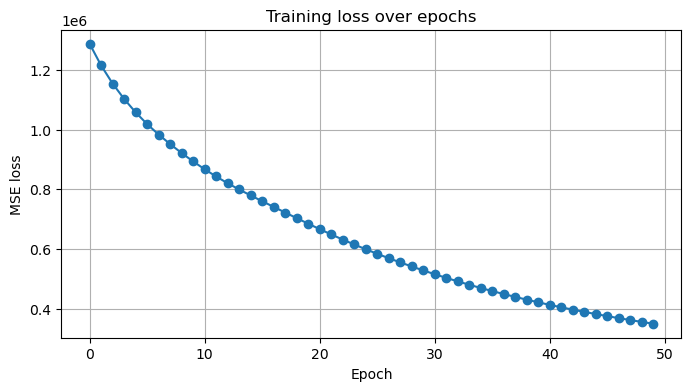

In [21]:
# Training loss Plot

plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker="o")
plt.title("Training loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.grid(True)
plt.show()

In [22]:
## Test evaluation step. It is for checking how well the trained model works on data it has not seen before:

model.eval()
with torch.no_grad():
    test_pred = model(X_test_tensor)
    test_loss = criterion(test_pred, y_test_tensor)
    predictions = test_pred.numpy()

print("Average test loss:", test_loss.item())

# Test MAE
mae = mean_absolute_error(y_test.flatten(), predictions.flatten())
print("Test MAE:", round(mae, 2))

Average test loss: 393791.09375
Test MAE: 354.8


The above output shows that the squared prediction error on unseen test set is quite larte
Average test loss: 393791.09375
Test MAE: 354.8

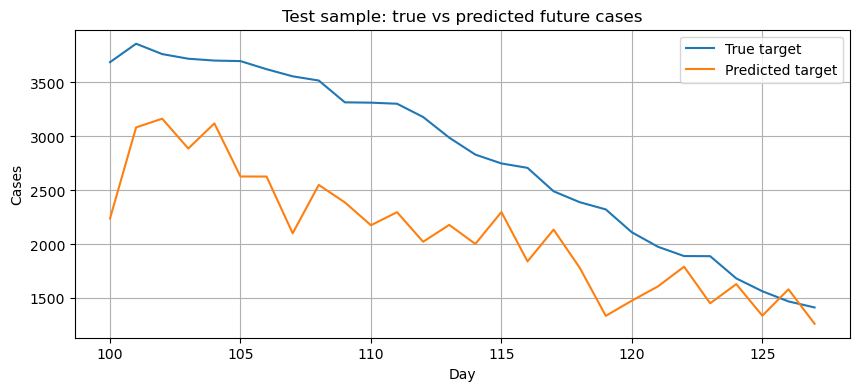

In [23]:
# prediction plot for one test example
# shows whether the predicted curve follows the real curve

with torch.no_grad():
    sample_prediction = model(X_test_tensor[0:1]).numpy()[0]

sample_true = y_test_tensor[0].numpy()
x_target = np.arange(input_days, input_days + target_days)

plt.figure(figsize=(10, 4))
plt.plot(x_target, sample_true, label="True target")
plt.plot(x_target, sample_prediction, label="Predicted target")

plt.title("Test sample: true vs predicted future cases")
plt.xlabel("Day")
plt.ylabel("Cases")
plt.grid(True)
plt.legend()
plt.show()

# The above code takes one test outbreak, gets the model's predictions for next 28 days, 
# then plots it against the true values so we can see how sell the model performed




- The above plot compares the true future cases with the predicted future cases for one test sample.
- Blue Line is real target and the orange is the line that the model prediction
- The predicted line follows the downward trend but it is lower than the true curve.
- Blue line starts at around 3700 cases but the orange line starts much lower at around 2200
- The model is not matching the exact values very well. It underestimates the cases count
- The model has still a lot of room for improvement
